NDIF API KEY

In [1]:
import os

def in_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

api_key = None
if in_colab():
    from google.colab import userdata
    api_key = userdata.get("NDIF_API_KEY")
else:
    api_key = os.environ.get("NDIF_API_KEY")

if api_key is None:
    os.environ["NDIF_API_KEY"] = input("Enter NDIF API key: ")

In [2]:
import torch
from typing import Union, List, Dict
from nnsight import LanguageModel

c:\Users\Claire Schlesinger\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Model Loading

If you set `REMOTE=True` then the model weights will not actually be loaded in your local environment and will instead use the remote NDIF execution.

In [3]:
REMOTE = True

In [4]:
import nnsight
def load_model(model_name, remote=True):
    if not nnsight.is_model_running(model_name):
        print(nnsight.ndif_status())
        raise ValueError(f"Model {model_name} is not currently available on NDIF")

    model = LanguageModel(model_name, device_map="auto", dispatch=not remote)

    print(f"Loading model {model_name} | {'Remote' if remote else 'Local'} Execution Mode")

    return model

model = load_model(input("Enter model key: ") or "meta-llama/Llama-3.1-8B", remote=REMOTE)

Loading model meta-llama/Llama-3.1-8B | Remote Execution Mode


In [5]:
DEF_BLOCK = (
    "DEFINITION OF UNCERTAINTY (Second-Moment):\n\n"

    "Uncertainty measures the VARIANCE or SPREAD of possible outcomes, "
    "not the expected value of outcomes.\n\n"

    "EXAMPLES:\n"
    "UNCERTAINTY (variance):\n"
    "- 'Revenue could be anywhere from $50M to $200M' → wide range\n"
    "- 'It depends on whether the regulation passes' → binary outcomes far apart\n"
    "- 'Roll two dice' → 11 possible sums with different probabilities\n\n"

    "NO UNCERTAINTY (zero variance):\n"
    "- 'Revenue will be $100M' → single outcome\n"
    "- 'We will lose $50M due to the tariff' → bad but certain\n"
    "- '2 + 2 = 4' → deterministic\n\n"

    "KEY PRINCIPLE NOT ABOUT SENTIMENT:\n"
    "- 'We expect difficult market conditions' → negative sentiment, but if the difficulty is certain, this is LOW uncertainty\n"
    "- 'Sales will definitely drop 20%' → bad news but NO uncertainty\n"
)


prompt_lead = DEF_BLOCK + "\n\nRespond only one word: Yes or no depending on if the phrase meets the definition of uncertainty:\n\nPhrase: 2+2=4\n\nResponse: no\n\nPhrase: The outcome of a 6 sided die\n\nResponse: yes\n\nPhrase: "
prompt_end = "\n\nResponse:"


In [6]:
import json
with open('../synthetic_data/econ_uncertainty_400_robust.json') as f:
    examples = json.load(f)

In [7]:
no_uncertainty = [e for e in examples if e['uncertainty'] == 'no']
yes_uncertainty = [e for e in examples if e['uncertainty'] == 'low']

In [8]:
no_uncertainty_prompts = [prompt_lead + e['statement'] + prompt_end for e in no_uncertainty]
yes_uncertainty_prompts = [prompt_lead + e['statement'] + prompt_end for e in yes_uncertainty]

In [9]:
def get_activations(prompts) -> Dict[str, torch.Tensor]:
    """
    Runs activation patching.

    Args:
        prompt: The prompt to get activations at each layer for.

    Returns:
        Dict[str, torch.Tensor]: Dictionary containing:
            - "source_logits": Logits for the source prompt after one forward pass ([1, vocab_size])
            - "target_logits_clean": Logits for the target prompt without patching ([1, vocab_size])
            - "target_logits_patched": Dictionary mapping each layer index (str) to patched logits ([1, vocab_size])
    """
    
    with torch.no_grad():
        with model.session(remote=not model.dispatched):
            with model.trace() as tracer:
                activations_per_prompt_per_layer = dict().save()
                for i in range(len(model.model.layers)):
                    with tracer.invoke(prompts):
                        hs = model.model.layers[i].output

                        if isinstance(hs, tuple):
                            hs = hs[0]
                        activations = hs.mean(dim=1).detach().cpu()
                        for prompt, activation in zip(prompts, activations):
                            if prompt not in activations_per_prompt_per_layer:
                                activations_per_prompt_per_layer[prompt] = list()
                            activations_per_prompt_per_layer[prompt].append(activation.float().numpy().tolist())

    return activations_per_prompt_per_layer

In [10]:
get_activations(no_uncertainty_prompts[0:4])

⬇ Downloading: 100%|██████████| 4.73M/4.73M [00:02<00:00]


{"DEFINITION OF UNCERTAINTY (Second-Moment):\n\nUncertainty measures the VARIANCE or SPREAD of possible outcomes, not the expected value of outcomes.\n\nEXAMPLES:\nUNCERTAINTY (variance):\n- 'Revenue could be anywhere from $50M to $200M' → wide range\n- 'It depends on whether the regulation passes' → binary outcomes far apart\n- 'Roll two dice' → 11 possible sums with different probabilities\n\nNO UNCERTAINTY (zero variance):\n- 'Revenue will be $100M' → single outcome\n- 'We will lose $50M due to the tariff' → bad but certain\n- '2 + 2 = 4' → deterministic\n\nKEY PRINCIPLE NOT ABOUT SENTIMENT:\n- 'We expect difficult market conditions' → negative sentiment, but if the difficulty is certain, this is LOW uncertainty\n- 'Sales will definitely drop 20%' → bad news but NO uncertainty\n\n\nRespond only one word: Yes or no depending on if the phrase meets the definition of uncertainty:\n\nPhrase: 2+2=4\n\nResponse: no\n\nPhrase: The outcome of a 6 sided die\n\nResponse: yes\n\nPhrase: The tr

In [11]:
no_uncertainty_activations = dict()
for i in range(0, 100, 4):
    no_uncertainty_activations.update(get_activations(no_uncertainty_prompts[i:i+4]))

⬇ Downloading: 100%|██████████| 4.73M/4.73M [00:00<00:00]


⬇ Downloading: 100%|██████████| 4.73M/4.73M [00:01<00:00]


⬇ Downloading: 100%|██████████| 4.73M/4.73M [00:00<00:00]


⬇ Downloading: 100%|██████████| 4.73M/4.73M [00:00<00:00]


⬇ Downloading: 100%|██████████| 4.73M/4.73M [00:00<00:00]


...

⬇ Downloading: 100%|██████████| 4.73M/4.73M [00:00<00:00]


⬇ Downloading: 100%|██████████| 4.73M/4.73M [00:00<00:00]


⬇ Downloading: 100%|██████████| 4.73M/4.73M [00:00<00:00]


⬇ Downloading: 100%|██████████| 4.73M/4.73M [00:00<00:00]


⬇ Downloading: 100%|██████████| 4.73M/4.73M [00:00<00:00]


In [12]:
yes_uncertainty_activations = dict()
for i in range(0, 100, 4):
    yes_uncertainty_activations.update(get_activations(yes_uncertainty_prompts[i:i+4]))

⬇ Downloading: 100%|██████████| 4.73M/4.73M [00:00<00:00]


⬇ Downloading: 100%|██████████| 4.73M/4.73M [00:00<00:00]


⬇ Downloading: 100%|██████████| 4.73M/4.73M [00:00<00:00]


⬇ Downloading: 100%|██████████| 4.73M/4.73M [00:02<00:00]


⬇ Downloading: 100%|██████████| 4.73M/4.73M [00:00<00:00]


...

⬇ Downloading: 100%|██████████| 4.73M/4.73M [00:00<00:00]


⬇ Downloading: 100%|██████████| 4.73M/4.73M [00:00<00:00]


⬇ Downloading: 100%|██████████| 4.73M/4.73M [00:00<00:00]


⬇ Downloading: 100%|██████████| 4.73M/4.73M [00:00<00:00]


⬇ Downloading: 100%|██████████| 4.73M/4.73M [00:00<00:00]


In [13]:
from pathlib import Path
save_dir = Path("model_activations")
save_dir.mkdir(exist_ok=True)
with save_dir.joinpath("no_uncertainty_activations.json").open("wt+") as f:
    json.dump(no_uncertainty_activations, f)
with save_dir.joinpath("yes_uncertainty_activations.json").open("wt+") as f:
    json.dump(yes_uncertainty_activations, f)

# Start here for already made activations

In [1]:
from pathlib import Path
import json
save_dir = Path("model_activations")
with save_dir.joinpath("no_uncertainty_activations.json").open() as f:
    no_uncertainty_activations = json.load(f)
with save_dir.joinpath("yes_uncertainty_activations.json").open() as f:
    yes_uncertainty_activations = json.load(f)

In [2]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

def build_layerwise_probes(dict_class0, dict_class1, test_size=0.2, random_state=42):
    sample_key = next(iter(dict_class0))
    L, D = np.asarray(dict_class0[sample_key]).shape

    layer_results = {}

    for layer in range(L):
        X = []
        y = []

        for activations in dict_class0.values():
            X.append(np.asarray(activations)[layer])
            y.append(0)

        for activations in dict_class1.values():
            X.append(np.asarray(activations)[layer])
            y.append(1)

        X = np.stack(X)
        y = np.array(y)

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=test_size,
            stratify=y,
            random_state=random_state
        )

        clf = make_pipeline(
            LogisticRegression(max_iter=5000)
        )

        clf.fit(X_train, y_train)
        acc = clf.score(X_test, y_test)

        layer_results[layer] = acc
        print(f"Layer {layer}: {acc:.4f}")

    return layer_results


In [6]:
layer_results = build_layerwise_probes(no_uncertainty_activations, yes_uncertainty_activations)

Layer 0: 0.5000
Layer 1: 0.5000
Layer 2: 0.5000
Layer 3: 0.5278
Layer 4: 0.5278
Layer 5: 0.5833
Layer 6: 0.6944
Layer 7: 0.8611
Layer 8: 0.8611
Layer 9: 0.8889
Layer 10: 0.9167
Layer 11: 0.9167
Layer 12: 0.9167
Layer 13: 1.0000
Layer 14: 1.0000
Layer 15: 1.0000
Layer 16: 1.0000
Layer 17: 1.0000
Layer 18: 1.0000
Layer 19: 1.0000
Layer 20: 1.0000
Layer 21: 1.0000
Layer 22: 1.0000
Layer 23: 1.0000
Layer 24: 1.0000
Layer 25: 1.0000
Layer 26: 1.0000
Layer 27: 1.0000
Layer 28: 1.0000
Layer 29: 1.0000
Layer 30: 1.0000
Layer 31: 1.0000


In [7]:
import matplotlib.pyplot as plt

def plot_layerwise_accuracy(layer_results, add_chance_line=True, save_path=None):
    layers = sorted(layer_results.keys())
    accuracies = [layer_results[layer] for layer in layers]

    plt.figure()
    plt.plot(layers, accuracies, marker='o')
    plt.xlabel("Layer")
    plt.ylabel("Accuracy")
    plt.title("Linear Probe Accuracy vs Layer")

    if add_chance_line:
        plt.axhline(y=0.5)

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()

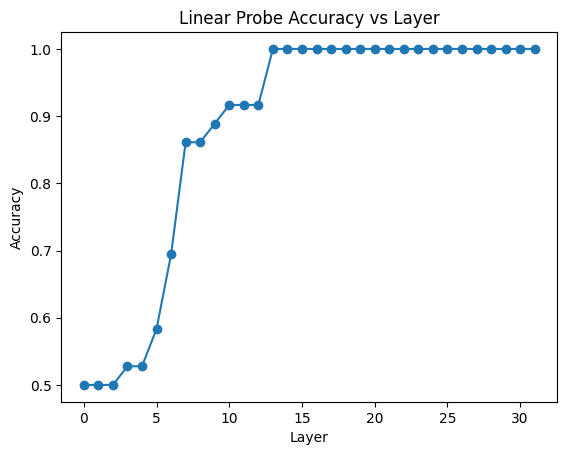

In [9]:
plot_layerwise_accuracy(layer_results, add_chance_line=False)